Autor: Joel Minj
Core Design: Activity 6

Using OpenMC 0.15.1 and Python 3.13.2

Initialization

In [ ]:
import glob
from math import log10, sqrt, pi
import matplotlib.pyplot as plt
import numpy as np
import openmc
import os
import logging
import openmc.deplete
import copy

from openmc import config
config['cross_sections'] = r'cross_sections.xml'

[studiojkm:03951] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.studiojkm.1000/jf.0/3225026560/shared_mem_cuda_pool.studiojkm could be created.
[studiojkm:03951] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [2]:
model = openmc.Model()

Remove past files

In [ ]:
def safe_remove(file_path):
    try:
        os.remove(file_path)
        logging.info(f"Removed file: {file_path}")
    except FileNotFoundError:
        logging.warning(f"File not found: {file_path}")
    except Exception as e:
        logging.error(f"Error removing file {file_path}: {e}")

# Remove past files
files_to_remove = [f for f in os.listdir('.') if not f.endswith('.ipynb')]

for file in files_to_remove:
    safe_remove(file)

Materials

In [ ]:
mod_temp = 586.325  # Temperature moderator
fuel_temp = 900  # Temperature fuel
p = 155  # Pressure in bar
enrichment = 3

densF = 10.0701  # Density of fuel
densM = openmc.data.water_density(mod_temp, (p/10))  # Density in g/cm^3

# Atomic weights
M_U = openmc.data.atomic_weight('U')
M_O = openmc.data.atomic_weight('O')
M_H = openmc.data.atomic_weight('H')
M_Gd = openmc.data.atomic_weight('Gd')

# Correct formulas for molecular weight
M_UO2 = M_U + 2 * M_O
M_H2O = 2 * M_H + M_O
M_Gd2O3 = 2 * M_Gd + 3 * M_O

# Fractions of weight of the materials: Fuel (F), Moderator (M)
wF_U = M_U / M_UO2
wF_O = (2 * M_O) / M_UO2
wM_H = (2 * M_H) / M_H2O
wM_O = M_O / M_H2O

# Fuel (UO2)
fuel = openmc.Material(name='UO2')
fuel.temperature = fuel_temp
fuel.add_element('U', 1.0, enrichment=enrichment)  # Specify enrichment here
fuel.add_element('O', 2.0)
fuel.set_density('g/cm3', densF)
fuel.depletable = True

# Moderator (Water)
moderator = openmc.Material(name='Water')
moderator.temperature = mod_temp
moderator.add_element('H', 2.0)
moderator.add_element('O', 1.0)
moderator.set_density('g/cm3', densM)
moderator.add_s_alpha_beta('c_H_in_H2O')
moderator.depletable = False

# Cladding and Guide Tube Material (Zircalloy-4)
zircaloy = openmc.Material(name='Zircaloy-4')
zircaloy.set_density('g/cm3', 5.8213)
zircaloy.temperature = 600
zircaloy.add_element('Zr', 0.99689)
zircaloy.add_element('Fe', 0.0021067)  # Corrected Iron
zircaloy.add_element('Cr', 0.0010033)  # Corrected Chromium
zircaloy.add_element('Sn', 0.0009967)  # Added Tin - typical Zircaloy composition
zircaloy.add_element('O', 0.00000001)   # Just to ensure
zircaloy.depletable = False

# Composition of bar with burnable poison (P). Gadolinia Gd2O3
eGdO = 0.095  # Enrichment of Gd2O3 in the poison + fuel bar
eGd154 = 0.0218  # Natural isotopic composition of Gd
eGd155 = 0.148
eGd156 = 0.2047
eGd157 = 0.1565
eGd158 = 0.2484
eGd160 = 0.2186 # Added for completeness


# Fuel with Burnable Poison (Gd2O3, 9.5% enrichment of 203Gd)
fuel_poison = openmc.Material(name='UO2+Gd2O3')
fuel_poison.set_density('g/cm3', densF) # Same density as normal fuel

# UO2 part
fuel_poison.add_element('U', (1-eGdO), enrichment=enrichment)
fuel_poison.add_element('O', 2*(1-eGdO))

# Gd2O3 part
fuel_poison.add_nuclide('Gd154', eGdO * eGd154 * openmc.data.atomic_mass('Gd154') / M_Gd2O3)
fuel_poison.add_nuclide('Gd155', eGdO * eGd155 * openmc.data.atomic_mass('Gd155') / M_Gd2O3)
fuel_poison.add_nuclide('Gd156', eGdO * eGd156 * openmc.data.atomic_mass('Gd156') / M_Gd2O3)
fuel_poison.add_nuclide('Gd157', eGdO * eGd157 * openmc.data.atomic_mass('Gd157') / M_Gd2O3)
fuel_poison.add_nuclide('Gd158', eGdO * eGd158 * openmc.data.atomic_mass('Gd158') / M_Gd2O3)
fuel_poison.add_nuclide('Gd160', eGdO * eGd160 * openmc.data.atomic_mass('Gd160') / M_Gd2O3)
fuel_poison.add_element('O', 3*eGdO)
fuel_poison.depletable = False

# Instrument Tube Material (Zircalloy-4) - Same as cladding
# AgInCd Alloy (Control Rod Material)
agincd = openmc.Material(name='AgInCd')
agincd.add_element('Ag', 0.80)
agincd.add_element('In', 0.15)
agincd.add_element('Cd', 0.05)
agincd.set_density('g/cm3', 10.17)
agincd.depletable = False


model.materials = openmc.Materials([fuel, zircaloy, moderator, fuel_poison, agincd])

model.materials.export_to_xml()

Geometry

In [ ]:
# Dimensions (in cm)
fuel_rod_pitch = 1.26  # cm
fuel_rod_outer_radius = 9.5/20 # cm
fuel_rod_inner_radius = 8.36/20 # cm
cladding_thickness = 0.57/10 # cm
fuel_pellet_radius = 8.19/20 # cm
guide_tube_inner_radius = 11.05/20  # cm
guide_tube_outer_radius = 12.09/20 # cm
instrument_tube_inner_radius = 11.428/20 # cm
instrument_tube_outer_radius = 12.24/20 # cm


# Create cylinders for the fuel and clad
fuel_outer_radius = openmc.ZCylinder(r=fuel_pellet_radius) 
clad_outer_radius = openmc.ZCylinder(r=fuel_rod_outer_radius)


# Create boundary planes to surround the geometry
assembly_width = 17 * fuel_rod_pitch
assembly_height = 365.8  # cm

#Define Universes

# Create a Universe to encapsulate a fuel pin
fuel_pin_universe = openmc.Universe(name='Fuel Pin')


# Create fuel Cell
fuel_cell = openmc.Cell(name='Fuel')
fuel_cell.fill = fuel
fuel_cell.region = -fuel_outer_radius
fuel_pin_universe.add_cell(fuel_cell)


# Create a clad Cell
clad_cell = openmc.Cell(name='Clad')
clad_cell.fill = zircaloy
clad_cell.region = +fuel_outer_radius & -clad_outer_radius
fuel_pin_universe.add_cell(clad_cell)


# Create a moderator Cell
moderator_cell = openmc.Cell(name='Moderator')
moderator_cell.fill = moderator  
moderator_cell.region = +clad_outer_radius
fuel_pin_universe.add_cell(moderator_cell)


# Create a Universe to encapsulate a fuel pin with burnable poison
fuel_pin_poison_universe = openmc.Universe(name='Fuel Pin Poison')


# Create fuel Cell
fuel_poison_cell = openmc.Cell(name='Fuel Poison')
fuel_poison_cell.fill = fuel_poison
fuel_poison_cell.region = -fuel_outer_radius
fuel_pin_poison_universe.add_cell(fuel_poison_cell)


# Create a clad Cell
clad_poison_cell = openmc.Cell(name='Clad Poison')
clad_poison_cell.fill = zircaloy
clad_poison_cell.region = +fuel_outer_radius & -clad_outer_radius
fuel_pin_poison_universe.add_cell(clad_poison_cell)


# Create a moderator Cell
moderator_poison_cell = openmc.Cell(name='Moderator Poison')
moderator_poison_cell.fill = moderator
moderator_poison_cell.region = +clad_outer_radius
fuel_pin_poison_universe.add_cell(moderator_poison_cell)


# Create a Universe to encapsulate a control rod guide tube
guide_tube_universe = openmc.Universe(name='Guide Tube')


# Create guide tube Cell
guide_tube_cell = openmc.Cell(name='Guide Tube Water')
guide_tube_cell.fill = moderator
guide_tube_cell.region = -fuel_outer_radius
guide_tube_universe.add_cell(guide_tube_cell)


# Create a clad Cell
clad_guide_cell = openmc.Cell(name='Guide Clad')
clad_guide_cell.fill = zircaloy
clad_guide_cell.region = +fuel_outer_radius & -clad_outer_radius
guide_tube_universe.add_cell(clad_guide_cell)

# Create a moderator Cell
moderator_guide_cell = openmc.Cell(name='Guide Tube Moderator')
moderator_guide_cell.fill = moderator
moderator_guide_cell.region = +clad_outer_radius
guide_tube_universe.add_cell(moderator_guide_cell)


# Create a Universe to encapsulate a control rod pin
control_rod_pin_universe = openmc.Universe(name='Control Rod Pin')


# Create control rod Cell
control_rod_cell = openmc.Cell(name='Control Rod')
control_rod_cell.fill = agincd
control_rod_cell.region = -fuel_outer_radius
control_rod_pin_universe.add_cell(control_rod_cell)


# Create a clad Cell
clad_control_cell = openmc.Cell(name='Clad Control Rod')
clad_control_cell.fill = zircaloy
clad_control_cell.region = +fuel_outer_radius & -clad_outer_radius
control_rod_pin_universe.add_cell(clad_control_cell)


# Create a moderator Cell
moderator_control_cell = openmc.Cell(name='Moderator Control Rod')
moderator_control_cell.fill = moderator
moderator_control_cell.region = +clad_outer_radius
control_rod_pin_universe.add_cell(moderator_control_cell)

# Create a Universe to encapsulate an instrument tube
instrument_tube_universe = openmc.Universe(name='Instrument Tube')

# Create the outer cylinder for the instrument tube
instrument_tube_outer_cylinder = openmc.ZCylinder(r=instrument_tube_outer_radius)

# Create the inner cylinder (void) for the instrument tube
instrument_tube_inner_cylinder = openmc.ZCylinder(r=instrument_tube_inner_radius)

# Create a cell for the moderator inside the instrument tube
instrument_tube_moderator_cell = openmc.Cell(name='Instrument Tube Moderator')
instrument_tube_moderator_cell.fill = moderator
instrument_tube_moderator_cell.region = -instrument_tube_inner_cylinder
instrument_tube_universe.add_cell(instrument_tube_moderator_cell)

# Create a cell for the zircaloy cladding of the instrument tube
instrument_tube_clad_cell = openmc.Cell(name='Instrument Tube Clad')
instrument_tube_clad_cell.fill = zircaloy
instrument_tube_clad_cell.region = +instrument_tube_inner_cylinder & -instrument_tube_outer_cylinder
instrument_tube_universe.add_cell(instrument_tube_clad_cell)

# Create a cell for the moderator outside the instrument tube
instrument_tube_outer_moderator_cell = openmc.Cell(name='Instrument Tube Outer Moderator')
instrument_tube_outer_moderator_cell.fill = moderator
instrument_tube_outer_moderator_cell.region = +instrument_tube_outer_cylinder
instrument_tube_universe.add_cell(instrument_tube_outer_moderator_cell)

Lattice Defination

In [6]:
# Moderator surrounding lattice of cells
moderator_cell = openmc.Cell(fill=moderator)
all_water = openmc.Universe(name='all_water', cells=[moderator_cell])


# Create fuel assembly Lattice
assembly = openmc.RectLattice(name='Fuel Assembly')
assembly.pitch = (fuel_rod_pitch, fuel_rod_pitch)
assembly.lower_left = [-assembly_width / 2] * 2
assembly.outer = all_water


# Positions of guide tubes (row, col) -  Adjust based on the figure on page 6 of the document
guide_tube_positions = [(2, 5), (2, 8), (2, 11),  
(5, 2), (5, 5), (5, 8), (5, 11), (5, 14),  
(8, 2), (8, 5), (8, 11), (8, 14),  
(11, 2), (11, 5), (11, 8), (11, 11), (11, 14), (14, 5), (14, 8), (14, 11)]

instrument_tube_position = (8, 8)


# Positions of fuel pins with burnable poison (row, col) - Adjust based on the figure on page 6 of the document
burnable_poison_positions = [(3, 3), (3, 13), (13, 3), (13, 13)]


# Initialize an empty 17x17 array of the lattice universes
universes = np.empty((17, 17), dtype=openmc.Universe)


# Fill the array with the fuel pin universes
universes[:, :] = fuel_pin_universe


# Replace universes with guide tubes and instrument tube at appropriate locations
for row, col in guide_tube_positions:
    universes[row, col] = guide_tube_universe

#Add instrument tube
row, col = instrument_tube_position
universes[row, col] = instrument_tube_universe

# Replace universes with control rods
for row, col in guide_tube_positions:
    universes[row, col] = all_water

# Replace fuel pins with burnable poison
for row, col in burnable_poison_positions:
       universes[row, col] = all_water

# Transpose the universes array
#universes = np.transpose(universes)

# Store the array of universes in the lattice
assembly.universes = universes

min_x_root = openmc.XPlane(x0=-assembly_width/2, boundary_type='reflective')
max_x_root = openmc.XPlane(x0=+assembly_width/2, boundary_type='reflective')
min_y_root = openmc.YPlane(y0=-assembly_width/2, boundary_type='reflective')
max_y_root = openmc.YPlane(y0=+assembly_width/2, boundary_type='reflective')
min_z_root = openmc.ZPlane(z0=-assembly_height / 2, boundary_type='reflective')
max_z_root = openmc.ZPlane(z0=+assembly_height / 2, boundary_type='reflective')

# Root cell containing the lattice
root_region = +min_x_root & -max_x_root & +min_y_root & -max_y_root & +min_z_root & -max_z_root
root_cell = openmc.Cell(name='Root Cell', fill=assembly, region=root_region)

# Root universe
root_universe = openmc.Universe(name='Root Universe')
root_universe.add_cell(root_cell)


# --- 2.4 Assign Geometry to Model ---
model.geometry = openmc.Geometry(root_universe)

# Export the geometry to XML
model.geometry.export_to_xml()

Geometry Plot

[studiojkm:06568] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.studiojkm.1000/jf.0/2490236928/shared_mem_cuda_pool.studiojkm could be created.
[studiojkm:06568] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
 Reading materials XML file...
 Reading geometry XML file...
 Preparing distributed cell instances...
 Reading plot XML file...

 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: fuel_assembly.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width: 21.42 21.42
Coloring: Materials
Basis: XY
Pixels: 1080 1080

 Processing plot 1: fuel_assembly.png...


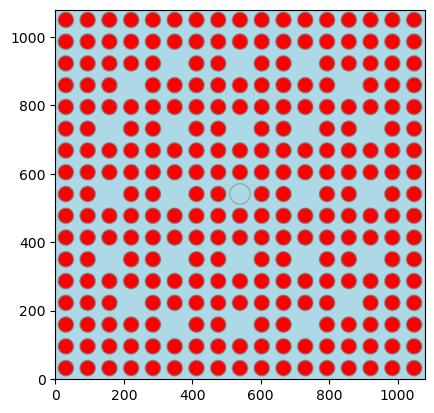

In [ ]:
plot = openmc.Plot()
plot.filename = 'fuel_assembly'
plot.width = [17 * fuel_rod_pitch, 17 * fuel_rod_pitch]
plot.pixels = [1080, 1080]
plot.color_by = 'material'
plot.origin = [0, 0, 0]
plot.basis = 'xy'

# color mapping for materials
plot.colors = {
    moderator: 'lightblue',
    fuel: 'red',
    zircaloy: 'grey',
    fuel_poison: 'red',
    agincd: 'black'
}

plots = openmc.Plots([plot])
plots.export_to_xml()

# Generate the plot
openmc.plot_geometry()

plt.imshow(plt.imread('fuel_assembly.png'), origin='lower')
plt.show()

In [8]:
# OpenMC simulation parameters
batches = 100
inactive = 20
particles = 1000


# Instantiate a Settings object
settings = openmc.Settings()
settings.batches = batches
settings.inactive = inactive
settings.particles = particles

settings.run_mode = 'eigenvalue'
settings.output = {'tallies': False}
settings.temperature = {'method':'interpolation'}


bounds = [-assembly_width/2, -assembly_width/2, -assembly_height/2,
        assembly_width/2, assembly_width/2, assembly_height/2]
uniform_dist = openmc.stats.Box(bounds[:3], bounds[3:], only_fissionable=False)
settings.source = openmc.Source(space=uniform_dist)



model.settings = settings

settings.export_to_xml()

/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)


Depletion Study

In [10]:
fuel.volume = pi * fuel_pellet_radius**2 * assembly_height 

time_steps = [720]*12 + [0.1]*12  # 12 monthly steps (~1 year) + 1.2h decay in 0.1h steps

power_levels = {
    '1 MW': [1e6]*12 + [0]*12,
    '2 MW': [2e6]*12 + [0]*12
}

# Portable chain file path
chain_file = "/home/joelminj/OpenMC/Depletion Chain/chain_endfb71_pwr.xml" 

results_files = []
for label, power in power_levels.items():
    model_copy = copy.deepcopy(model)
    operator = openmc.deplete.CoupledOperator(model_copy, chain_file)
    integrator = openmc.deplete.PredictorIntegrator(
        operator,
        time_steps,
        power=power,
        timestep_units='h'  
    )
    integrator.integrate()
    output_file = f'depletion_{label.replace(" ", "_")}.h5'
    os.rename('depletion_results.h5', output_file)
    results_files.append(output_file)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

          1200K
          2500K


 Reading Cd112 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cd112.h5
 Reading Cd113 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cd113.h5
 Reading Cd114 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cd114.h5
 Reading Cd116 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cd116.h5
 Reading In113 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/In113.h5
 Reading In115 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/In115.h5
 Reading c_H_in_H2O from
 /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/c_H_in_H2O.h5
 Minimum neutron data temperature: 250 K
 Maximum neutron data temperature: 2500 K
 Preparing distributed cell instances...
 Reading plot XML file...
 Writing summary.h5 file...
[openmc.deplete] t=0.0 s, dt=2592000.0 s, source=1000000.0
 Reading H3 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/H3.h5
 Reading He3 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/He3.h5
 Reading He4 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/He4.h5
 Readi

 Reading Mg26 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Mg26.h5
 Reading Al27 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Al27.h5
 Reading Si28 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Si28.h5
 Reading Si29 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Si29.h5
 Reading Si30 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Si30.h5
 Reading P31 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/P31.h5
 Reading S32 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/S32.h5
 Reading S33 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/S33.h5
 Reading S34 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/S34.h5
 Reading S36 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/S36.h5
 Reading Cl35 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cl35.h5
 Reading Cl37 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Cl37.h5
 Reading Ar36 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ar36.h5
 Reading Ar38 from /home/joelminj/OpenMC/endfb-v

 Reading Ar40 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ar40.h5
 Reading K39 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/K39.h5
 Reading K40 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/K40.h5
 Reading K41 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/K41.h5
 Reading Ca40 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca40.h5
 Reading Ca42 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca42.h5
 Reading Ca43 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca43.h5
 Reading Ca44 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca44.h5
 Reading Ca46 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca46.h5
 Reading Ca48 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ca48.h5
 Reading Sc45 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Sc45.h5
 Reading Ti46 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ti46.h5
 Reading Ti47 from /home/joelminj/OpenMC/endfb-vii.1-hdf5/neutron/Ti47.h5
 Reading Ti48 from /home/joelminj/OpenMC/end

...

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    0.58243
        2/1    0.65790
        3/1    0.65611
        4/1    0.66399
        5/1    0.59549
        6/1    0.61882
        7/1    0.65616
        8/1    0.68688
        9/1    0.65541
       10/1    0.64260
       11/1    0.60958
       12/1    0.66982
       13/1    0.62390
       14/1    0.68297
       15/1    0.60192
       16/1    0.60810
       17/1    0.65200
       18/1    0.62733
       19/1    0.64737
       20/1    0.63779
       21/1    0.66401
       22/1    0.66778    0.66590 +/- 0.00188
       23/1    0.61973    0.65051 +/- 0.01543
       24/1    0.62804    0.64489 +/- 0.01227
       25/1    0.60197    0.63631 +/- 0.01281
       26/1    0.60951    0.63184 +/- 0.01137
       27/1    0.62913    0.63146 +/- 0.00962
       28/1    0.66430    0.63556 +/- 0.00

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    0.58872
        2/1    0.59563
        3/1    0.57964
        4/1    0.62409
        5/1    0.63375
        6/1    0.60892
        7/1    0.60276
        8/1    0.66104
        9/1    0.62898
       10/1    0.64836
       11/1    0.64623
       12/1    0.65762
       13/1    0.64197
       14/1    0.62053
       15/1    0.60191
       16/1    0.64828
       17/1    0.62670
       18/1    0.64322
       19/1    0.59369
       20/1    0.61518
       21/1    0.64836
       22/1    0.64085    0.64461 +/- 0.00376
       23/1    0.61570    0.63497 +/- 0.00988
       24/1    0.62708    0.63300 +/- 0.00726
       25/1    0.67631    0.64166 +/- 0.01033
       26/1    0.62779    0.63935 +/- 0.00874
       27/1    0.62873    0.63783 +/- 0.00754
       28/1    0.58948    0.63179 +/- 0.00

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    0.61434
        2/1    0.58162
        3/1    0.61110
        4/1    0.64049
        5/1    0.63016
        6/1    0.60912
        7/1    0.60153
        8/1    0.66062
        9/1    0.59370
       10/1    0.63134
       11/1    0.62535
       12/1    0.64169
       13/1    0.66234
       14/1    0.56552
       15/1    0.59887
       16/1    0.58306
       17/1    0.60870
       18/1    0.59720
       19/1    0.59853
       20/1    0.59356
       21/1    0.58814
       22/1    0.56215    0.57515 +/- 0.01299
       23/1    0.59203    0.58077 +/- 0.00938
       24/1    0.59797    0.58507 +/- 0.00790
       25/1    0.61824    0.59171 +/- 0.00903
       26/1    0.59605    0.59243 +/- 0.00741
       27/1    0.63010    0.59781 +/- 0.00825
       28/1    0.62860    0.60166 +/- 0.00

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    0.56348
        2/1    0.62060
        3/1    0.60029
        4/1    0.54864
        5/1    0.61137
        6/1    0.62261
        7/1    0.61321
        8/1    0.61978
        9/1    0.54815
       10/1    0.59811
       11/1    0.56397
       12/1    0.57731
       13/1    0.59176
       14/1    0.61595
       15/1    0.57790
       16/1    0.57665
       17/1    0.61654
       18/1    0.56136
       19/1    0.61573
       20/1    0.59187
       21/1    0.59825
       22/1    0.58007    0.58916 +/- 0.00909
       23/1    0.61002    0.59611 +/- 0.00871
       24/1    0.62050    0.60221 +/- 0.00867
       25/1    0.61219    0.60421 +/- 0.00700
       26/1    0.63518    0.60937 +/- 0.00770
       27/1    0.56561    0.60312 +/- 0.00903
       28/1    0.65324    0.60938 +/- 0.01

 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    0.56882
        2/1    0.60164
        3/1    0.56375
        4/1    0.50342
        5/1    0.57155
        6/1    0.62949
        7/1    0.59063
        8/1    0.61213
        9/1    0.61010
       10/1    0.58229
       11/1    0.58678
       12/1    0.59775
       13/1    0.58373
       14/1    0.59530
       15/1    0.61338
       16/1    0.61598
       17/1    0.63510
       18/1    0.58319
       19/1    0.56695
       20/1    0.58143
       21/1    0.61859
       22/1    0.58943    0.60401 +/- 0.01458
       23/1    0.60778    0.60527 +/- 0.00851
       24/1    0.63265    0.61211 +/- 0.00911
       25/1    0.52521    0.59473 +/- 0.01876
       26/1    0.62531    0.59983 +/- 0.01614
       27/1    0.60344    0.60034 +/- 0.01365
       28/1    0.57254    0.59687 +/- 0.01

Depletion Study Plot

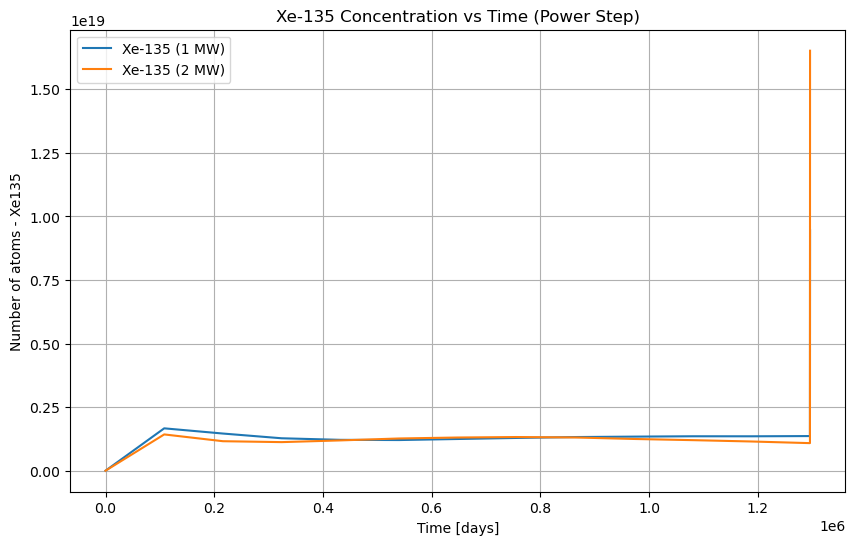

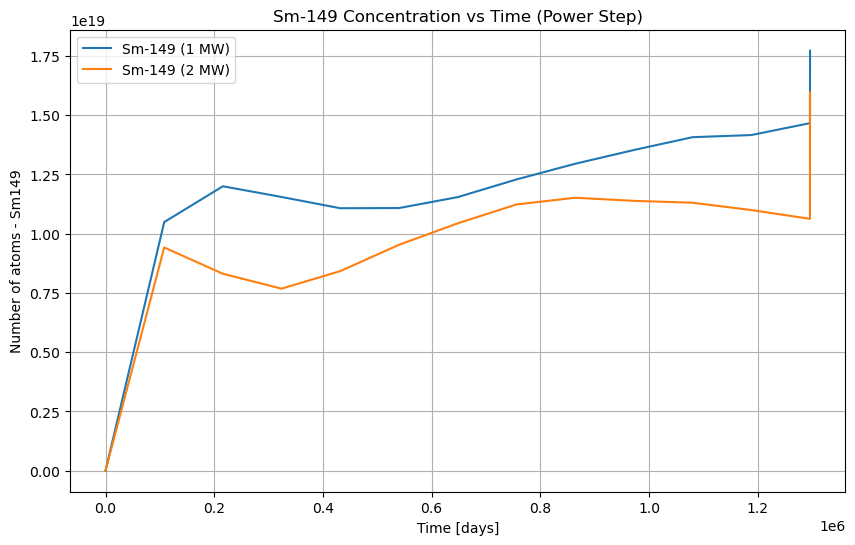

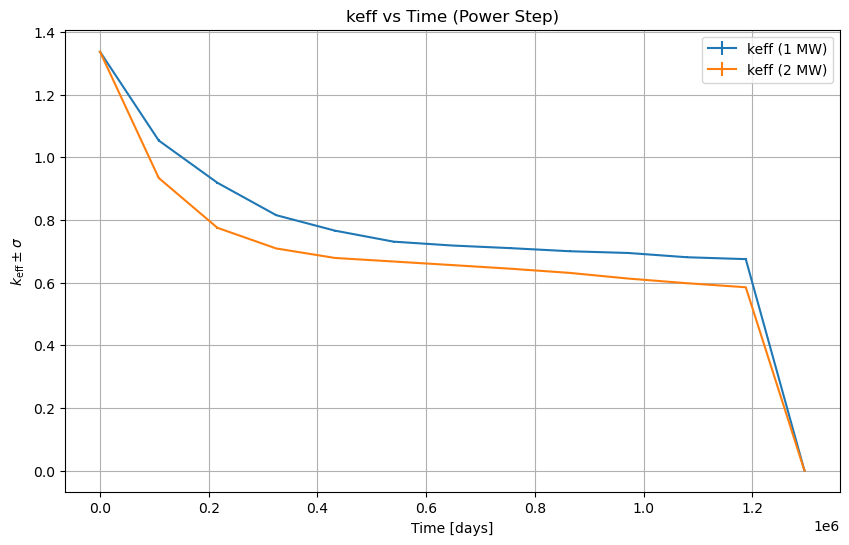

In [ ]:
labels = ['1 MW', '2 MW']

# Plot Xe-135, Sm-149 and keff 
plt.figure(figsize=(10, 6))
for idx, (results_file, label) in enumerate(zip(results_files, labels)):
    results = openmc.deplete.Results(results_file)
    time, k = results.get_keff()
    time /= 24  # convert hours to days
    _, xe135 = results.get_atoms('1', 'Xe135')
    plt.plot(time, xe135, label=f'Xe-135 ({label})')
plt.xlabel('Time [days]')
plt.ylabel('Number of atoms - Xe135')
plt.title('Xe-135 Concentration vs Time (Power Step)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for idx, (results_file, label) in enumerate(zip(results_files, labels)):
    results = openmc.deplete.Results(results_file)
    time, k = results.get_keff()
    time /= 24  # convert hours to days
    _, sm149 = results.get_atoms('1', 'Sm149')
    plt.plot(time, sm149, label=f'Sm-149 ({label})')
plt.xlabel('Time [days]')
plt.ylabel('Number of atoms - Sm149')
plt.title('Sm-149 Concentration vs Time (Power Step)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for idx, (results_file, label) in enumerate(zip(results_files, labels)):
    results = openmc.deplete.Results(results_file)
    time, k = results.get_keff()
    time /= 24  # convert hours to days
    plt.errorbar(time, k[:, 0], yerr=k[:, 1], label=f'keff ({label})')
plt.xlabel('Time [days]')
plt.ylabel(r'$k_{\mathrm{eff}} \pm \sigma$') 
plt.title('keff vs Time (Power Step)')
plt.legend()
plt.grid(True)
plt.show()

Burnup Depletion Study Plots

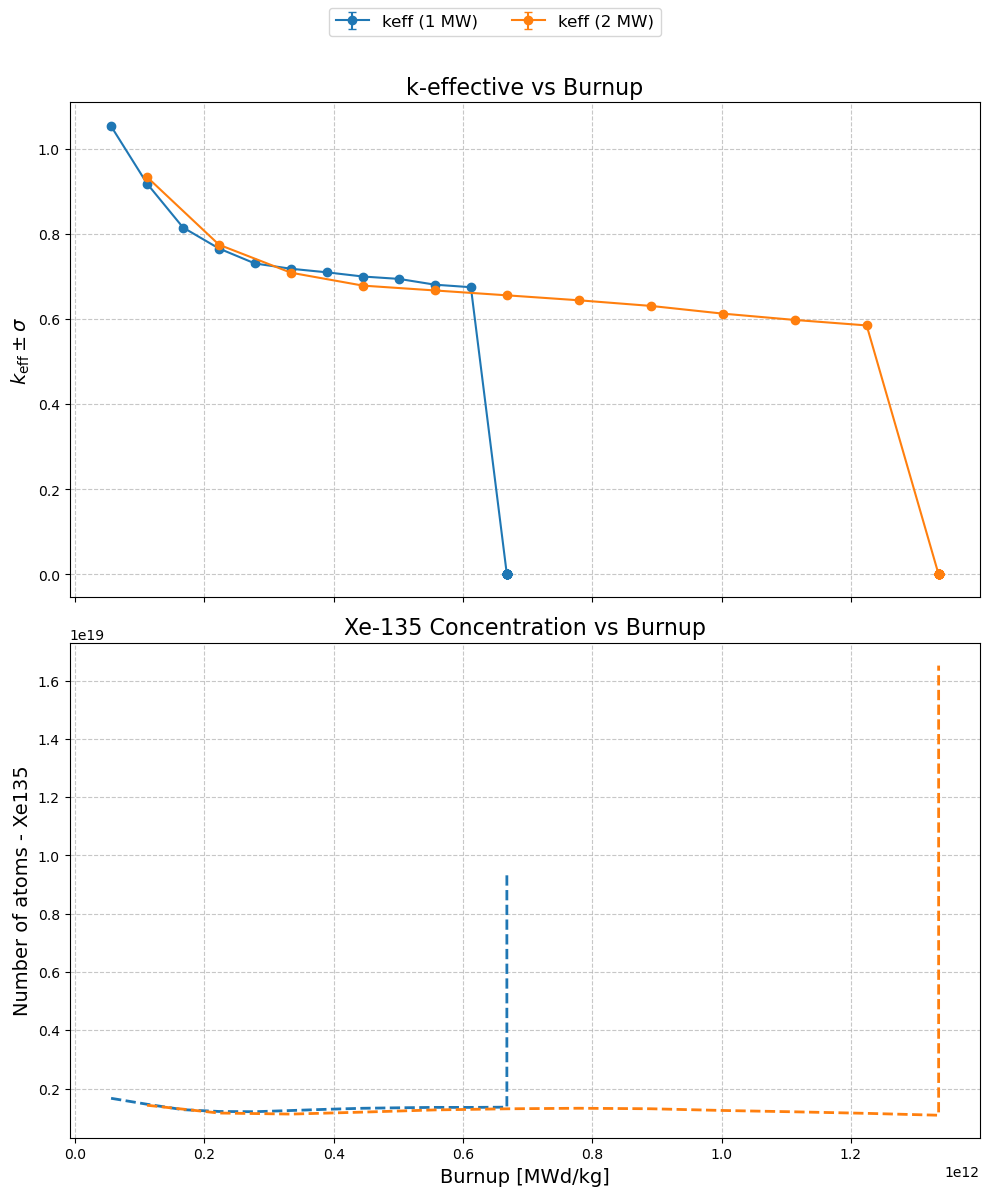

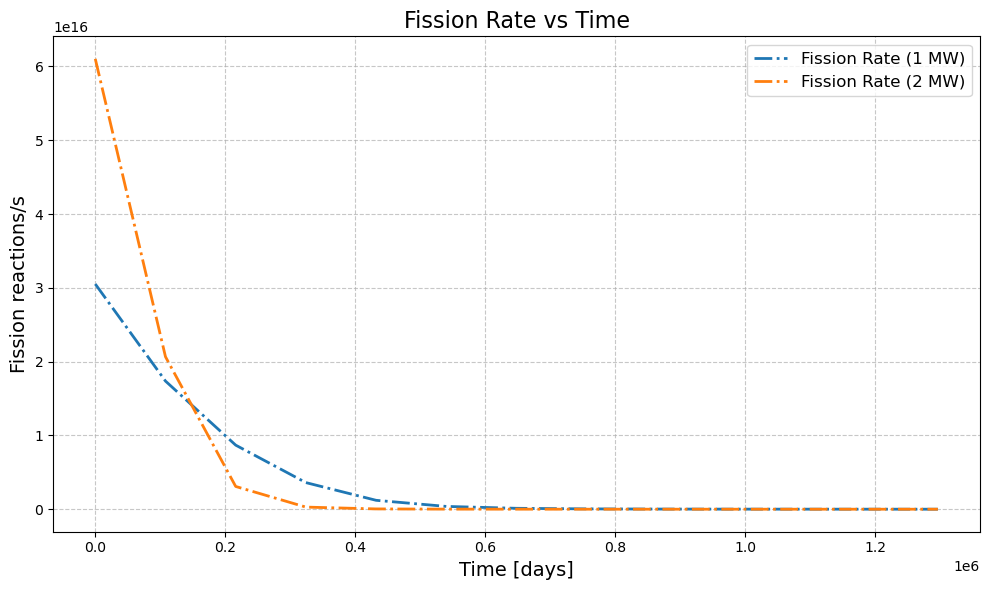

In [ ]:
import matplotlib.ticker as ticker

labels = list(power_levels.keys())
power_steps = list(power_levels.values())

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

for idx, (results_file, label, power) in enumerate(zip(results_files, labels, power_steps)):
    results = openmc.deplete.Results(results_file)
    time, k = results.get_keff()  # time in hours
    time_days = time / 24  # Convert to days

    # Calculate burnup [MWd/kg]
    fuel_mass_kg = fuel.volume * fuel.density / 1000  # Convert g to kg
    delta_time = np.diff(time) / 24  # Time step widths in days
    power = np.array(power[:len(delta_time)])  # Match length with delta_time
    incremental_burnup = power * delta_time / fuel_mass_kg  # MWd/kg
    burnup = np.cumsum(incremental_burnup)

    # Align k-effective values with burnup
    k_mean = k[1:, 0]
    k_std = k[1:, 1]

    # Plot k-effective vs Burnup
    axes[0].errorbar(burnup, k_mean, yerr=k_std, label=f'keff ({label})', fmt='-o', capsize=3)
    axes[0].set_ylabel(r'$k_{\mathrm{eff}} \pm \sigma$', fontsize=14)
    axes[0].set_title('k-effective vs Burnup', fontsize=16)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot Xe-135 vs Burnup
    _, xe135 = results.get_atoms('1', 'Xe135')
    axes[1].plot(burnup, xe135[1:], label=f'Xe-135 ({label})', linestyle='--', linewidth=2)
    axes[1].set_ylabel('Number of atoms - Xe135', fontsize=14)
    axes[1].set_title('Xe-135 Concentration vs Burnup', fontsize=16)
    axes[1].grid(True, linestyle='--', alpha=0.7)

# Shared X-axis
axes[-1].set_xlabel('Burnup [MWd/kg]', fontsize=14)

# Add a shared legend
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=2, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# fission rate plot
plt.figure(figsize=(10, 6))
for idx, (results_file, label) in enumerate(zip(results_files, labels)):
    results = openmc.deplete.Results(results_file)
    time, _ = results.get_keff()  # time in hours
    time_days = time / 24  # Convert to days

    # Plot Fission Rate vs Time
    try:
        nuclides, fission_rate = results.get_reaction_rate('1', 'U235', 'fission')
        if isinstance(fission_rate, np.ndarray) and fission_rate.ndim > 1:
            fission_rate = fission_rate[0]
        plt.plot(time_days, fission_rate, label=f'Fission Rate ({label})', linestyle='-.', linewidth=2)
    except Exception as e:
        print(f'Fission rate plot not available: {e}')

plt.xlabel('Time [days]', fontsize=14)
plt.ylabel('Fission reactions/s', fontsize=14)
plt.title('Fission Rate vs Time', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
